In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [2]:
import random

import numpy as np
import sentencepiece as spm

import torch
import torch.nn as nn

from torch.utils.data import IterableDataset
from torch.utils.data import DataLoader

from tqdm.auto import tqdm

from configs.config import config

c:\Users\FH\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
device = torch.device(
    config.device if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


In [4]:
from src.model import PersianGPT
from src.dataset import PersianDataset

In [5]:
token_file = config.train_file.parent / "tokens.bin"

tokens = np.memmap(
    token_file,
    dtype=np.uint16,
    mode="r"
)

dataset = PersianDataset(
    tokens,
    config.max_seq_len
)

dataloader = DataLoader(
    dataset,
    batch_size=config.batch_size,
    num_workers=0,
)

In [6]:
model = PersianGPT(config).to(device)

print(f"Device: {device}")

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
initial_weight = model.token_embedding.weight.detach().clone()

print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")

Device: cuda
Total Parameters     : 21,188,608
Trainable Parameters : 21,188,608


c:\Users\FH\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [7]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config.learning_rate,
    weight_decay=config.weight_decay
)

criterion = torch.nn.CrossEntropyLoss()

print(optimizer)

AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0003
    maximize: False
    weight_decay: 0.01
)


In [8]:
input_ids, target_ids = next(iter(dataloader))

input_ids = input_ids.to(device)
target_ids = target_ids.to(device)

print(input_ids.shape)
print(target_ids.shape)

torch.Size([16, 256])
torch.Size([16, 256])


In [9]:
model.train()

logits = model(input_ids)

print(logits.shape)

torch.Size([16, 256, 32000])


In [10]:
loss = criterion(
    logits.reshape(-1, config.vocab_size),
    target_ids.reshape(-1)
)

print(f"Initial Loss : {loss.item():.4f}")

Initial Loss : 10.5446


In [11]:
optimizer.zero_grad(set_to_none=True)

loss.backward()

print("Backward Successful ✅")

Backward Successful ✅


In [12]:
optimizer.step()

print("Optimizer Step Successful ✅")

Optimizer Step Successful ✅


In [13]:
changed = torch.equal(
    initial_weight,
    model.token_embedding.weight
)

print("Weights Changed:", not changed)

Weights Changed: True


In [14]:
loss_history = []

for step in range(20):

    optimizer.zero_grad(set_to_none=True)

    logits = model(input_ids)

    loss = criterion(
        logits.reshape(-1, config.vocab_size),
        target_ids.reshape(-1)
    )

    loss.backward()

    optimizer.step()

    loss_history.append(loss.item())

    print(f"Step {step+1:2d} | Loss = {loss.item():.4f}")

Step  1 | Loss = 10.3502
Step  2 | Loss = 10.1682
Step  3 | Loss = 9.9911
Step  4 | Loss = 9.8220
Step  5 | Loss = 9.6664
Step  6 | Loss = 9.5197
Step  7 | Loss = 9.3889
Step  8 | Loss = 9.2587
Step  9 | Loss = 9.1364
Step 10 | Loss = 9.0185
Step 11 | Loss = 8.8960
Step 12 | Loss = 8.7829
Step 13 | Loss = 8.6672
Step 14 | Loss = 8.5521
Step 15 | Loss = 8.4364
Step 16 | Loss = 8.3212
Step 17 | Loss = 8.2064
Step 18 | Loss = 8.0955
Step 19 | Loss = 7.9821
Step 20 | Loss = 7.8716


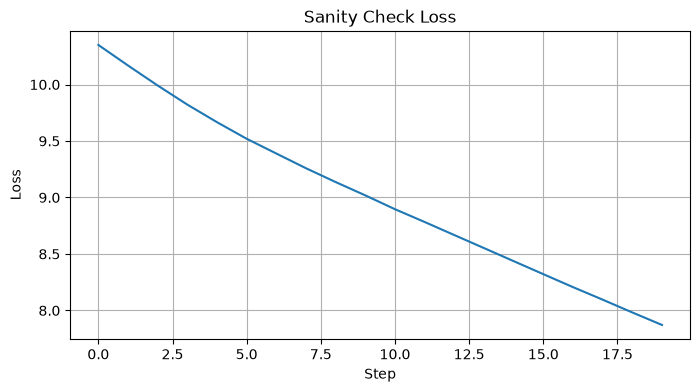

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.plot(loss_history)

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Sanity Check Loss")

plt.grid(True)

plt.show()

In [16]:
print(logits.shape)

torch.Size([16, 256, 32000])


In [17]:
print(torch.isnan(logits).any())
print(torch.isinf(logits).any())

tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
